# ICMS 150 (2 Day experiment summary)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [1]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df, build_pattern_stims_nominal
%load_ext autoreload
%autoreload 2
day1_datadir = "data/icms_150_6_2_26"
day2_datadir = "data/icms_150_6_3_26"
mode = "pca"

all_spikes_day1 = np.load(f"{day1_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
all_spikes_day2 = np.load(f"{day2_datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)

spikes_df_day1 = pd.DataFrame(all_spikes_day1)  # columns auto-named from dtype fields
spikes_df_day1.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day1.drop(columns=['segment_index'], inplace=True)

spikes_df_day2 = pd.DataFrame(all_spikes_day2)  # columns auto-named from dtype fields
spikes_df_day2.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df_day2.drop(columns=['segment_index'], inplace=True)

pattern_df_day1, min_pattern_timestamp_day1 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day1_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df_day2, min_pattern_timestamp_day2 = preprocess_pattern_stimulations_df(read_pattern_json(f"{day2_datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)

visual_stim_times_day1= np.load(f"{day1_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_times_day2= np.load(f"{day2_datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels_day1 = np.load(f"{day1_datadir}/VStim_Labels.npy") # 1600 
visual_stim_labels_day2 = np.load(f"{day2_datadir}/VStim_Labels.npy") # 1600

visual_orientation_degs1 = np.sort(np.unique(visual_stim_labels_day1))
visual_orientation_degs2 = np.sort(np.unique(visual_stim_labels_day2))
visual_trial_df1 = pd.DataFrame({
    'timestamp': visual_stim_times_day1,
    'orientation': visual_stim_labels_day1
})
visual_trial_df2 = pd.DataFrame({
    'timestamp': visual_stim_times_day2,
    'orientation': visual_stim_labels_day2
})
min_visual_timestamp_1 = visual_trial_df1['timestamp'].min()
max_visual_timestamp_1 = visual_trial_df1['timestamp'].max()
min_visual_timestamp_2 = visual_trial_df2['timestamp'].min()
max_visual_timestamp_2 = visual_trial_df2['timestamp'].max()

visual_spikes_1 = spikes_df_day1[(spikes_df_day1['timestamp'] >= min_visual_timestamp_1) & (spikes_df_day1['timestamp'] <= max_visual_timestamp_1)].copy()
visual_spikes_2 = spikes_df_day2[(spikes_df_day2['timestamp'] >= min_visual_timestamp_2) & (spikes_df_day2['timestamp'] <= max_visual_timestamp_2)].copy()

## Visual Tuning over 2 Days 

In [2]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
VIS_ORIENT_TIME = 600                         # overlay/target window (ms): oracle &
                                              # targeted stim avgs are summed over this
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

def make_avg_binned_responses(visual_spikes, visual_trial_df, visual_orientation_degs):
    all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
    n_neurons = len(all_neuron_ids)
    neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

    sum_responses = []
    for orientation in visual_orientation_degs:
        sum_response = np.zeros((n_neurons, N_BINS))
        for trial in range(N_VIS_TRIALS):
            trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
            trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                        (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
            if trial_spikes.empty:
                continue
            bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

            for neuron_id in trial_spikes['neuron_id'].unique():
                idx = neuron_to_idx[neuron_id]
                counts, _ = np.histogram(
                    trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                    bins=bin_edges,
                )
                sum_response[idx] += counts
        sum_response /= N_VIS_TRIALS  # average over trials 
        sum_responses.append(sum_response) 
    sum_responses = np.array(sum_responses)
    return sum_responses  # (n_orientations, n_neurons, N_BINS)


avg_vis_responses_1 = make_avg_binned_responses(visual_spikes_1, visual_trial_df1, visual_orientation_degs1)
avg_vis_responses_2 = make_avg_binned_responses(visual_spikes_2, visual_trial_df2, visual_orientation_degs2)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"avg_vis_responses1 shape (orient, neuron, time_bin): {avg_vis_responses_1.shape}")
print(f"avg_vis_responses2 shape (orient, neuron, time_bin): {avg_vis_responses_2.shape}")


Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
avg_vis_responses1 shape (orient, neuron, time_bin): (16, 63, 50)
avg_vis_responses2 shape (orient, neuron, time_bin): (16, 55, 50)


In [3]:
# ============================================================
# Shared projection + ring-plot helpers (used by every PCA/LDA cell below).
#
# build_projection() is the single source of truth for turning a population
# response matrix into a 2- or 3-axis basis and projecting points into it:
#   * PCA  -> top-2 principal components of the (orientation x neuron) matrix.
#   * LDA  -> top-2 linear discriminants fit on per-trial spike counts.
#   * include_cis=True prepends the population mean ("CIS") axis and
#     QR-orthonormalises the [mean, axis1, axis2] basis -> (n_neurons, 3).
#   * include_cis=False returns the raw 2-axis basis -> (n_neurons, 2).
#   * scale multiplies the response matrix before fitting/projecting (used to
#     rescale a 500 ms visual window up to the 600 ms target window).
#
# trial_counts() extracts per-(orientation, trial) total spike-count vectors,
# the input LDA needs. plot_ring() draws the standard HSV doubled-angle ring.
# ============================================================
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


def trial_counts(spikes, trial_df, orientation_degs, neuron_to_idx, window_ms,
                 n_neurons, n_trials=N_VIS_TRIALS):
    """Per-trial total spike counts over a `window_ms` window after each trial
    onset. Returns (counts (n_rows, n_neurons), labels (n_rows,))."""
    window_samples = (window_ms * SAMPLE_RATE) // 1000
    rows, labels = [], []
    for orientation in orientation_degs:
        for t0 in trial_df[trial_df['orientation'] == orientation]['timestamp'].values[:n_trials]:
            seg = spikes[(spikes['timestamp'] >= t0) &
                         (spikes['timestamp'] < t0 + window_samples)]
            v = np.zeros(n_neurons)
            if not seg.empty:
                for nid, c in seg.groupby('neuron_id').size().items():
                    if nid in neuron_to_idx:
                        v[neuron_to_idx[nid]] = c
            rows.append(v)
            labels.append(orientation)
    return np.array(rows), np.array(labels)


def build_projection(resp_matrix, mode="pca", include_cis=True, scale=1.0,
                     lda_trials=None, verbose=False):
    """Build a projection basis and project `resp_matrix` into it.

    resp_matrix : (n_points, n_neurons) summed-over-time response matrix.
    mode        : "pca" (components of resp_matrix) or "lda" (discriminants of
                  per-trial counts supplied via `lda_trials`).
    include_cis : prepend the population-mean axis and QR-orthonormalise
                  -> 3 axes; otherwise return the raw 2 axes.
    scale       : scalar applied to resp_matrix before fit/projection.
    lda_trials  : (counts, labels) tuple required when mode == "lda".

    Returns (proj (n_neurons, 2|3), coords (n_points, 2|3)).
    """
    X = resp_matrix * scale
    mean_vec = X.mean(axis=0, keepdims=True) # mean across orientations
    if mode == "pca":
        pca = PCA(n_components=2).fit(X)
        axes = [pca.components_[0], pca.components_[1]]
        if verbose:
            print("PCA explained variance ratio:", pca.explained_variance_ratio_)
    elif mode == "lda":
        counts, labels = lda_trials
        lda = LDA(n_components=2).fit(counts, labels.astype(str))
        axes = [lda.scalings_[:, 0], lda.scalings_[:, 1]]
        if verbose:
            print("LDA explained variance ratio:", lda.explained_variance_ratio_)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if include_cis:
        proj, _ = np.linalg.qr(np.array([mean_vec[0], axes[0], axes[1]]).T)  # (n_neurons, 3)
    else:
        proj = np.array(axes).T                                             # (n_neurons, 2)
    return proj, (X - mean_vec) @ proj, mean_vec


def plot_ring(coords, orientation_degs, title, axis_labels,
              trial_coords=None, trial_doubled=None):
    """HSV doubled-angle ring scatter (2-D or 3-D from coords' column count).
    Optionally overlays low-alpha per-trial points. Returns the figure."""
    is3d = coords.shape[1] == 3
    Scatter = go.Scatter3d if is3d else go.Scatter
    doubled = (np.array(orientation_degs) * 2) % 360
    fig = go.Figure()

    def _coords_kw(c):
        return (dict(x=c[:, 0], y=c[:, 1], z=c[:, 2]) if is3d
                else dict(x=c[:, 0], y=c[:, 1]))

    if trial_coords is not None:
        fig.add_trace(Scatter(
            **_coords_kw(trial_coords), mode='markers',
            marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                        cmin=0, cmax=360, opacity=0.05, line=dict(width=0)),
            name='Individual trials', hovertemplate='trial<extra></extra>',
            showlegend=True))

    fig.add_trace(Scatter(
        **_coords_kw(coords), mode='markers+text',
        marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                    colorbar=dict(title='Orientation (°)',
                                  tickvals=np.arange(0, 361, 72),
                                  ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)]),
                    line=dict(color='black', width=1)),
        text=[f'{int(o)}°' for o in orientation_degs],
        textposition='top center', name='Orientation average'))

    if is3d:
        fig.update_layout(title=title, width=800, height=700,
                          scene=dict(xaxis_title=axis_labels[0],
                                     yaxis_title=axis_labels[1],
                                     zaxis_title=axis_labels[2], aspectmode='data'))
    else:
        fig.update_layout(title=title, width=700, height=600,
                          xaxis_title=axis_labels[0], yaxis_title=axis_labels[1])
    return fig


In [4]:
# Visual-tuning ring: project per-orientation average responses into a PCA or
# LDA basis (optionally with the CIS/mean axis) and draw the ring, overlaying
# low-alpha per-trial points. Thin wrapper over the shared helpers above.
#
# NOTE ON TIMESCALE: visual responses are summed over STIM_MS (500 ms), but the
# oracle / targeted stim averages overlaid in later cells are summed over
# VIS_ORIENT_TIME (600 ms). To keep one consistent space, `scale` rescales the
# visual responses up to the 600 ms window (default VIS_ORIENT_TIME/STIM_MS),
# exactly as build_projection does in the trajectory cell. The returned `proj`
# and `mean_vec` are therefore on the 600 ms scale, so 600 ms overlays can be
# projected with (X - mean_vec) @ proj and no extra factor.
def make_ring(avg_responses, visual_orientation_degs, visual_trial_df, visual_spikes,
              mode="pca", proj=None, include_CIS=True, scale=None):
    if scale is None:
        scale = VIS_ORIENT_TIME / STIM_MS          # 600 / 500 -> match overlay window
    n_neurons = avg_responses.shape[1]
    neuron_to_idx = {n: i for i, n in enumerate(np.sort(visual_spikes['neuron_id'].unique()))}
    sum_responses = avg_responses.sum(axis=-1)             # (n_orient, n_neurons) per-orientation averages

    # Build the basis (unless caller supplied one). LDA fits on per-trial counts
    # over a 600 ms window; PCA fits on the per-orientation averages. The `scale`
    # is applied inside build_projection so proj/mean_vec are on the 600 ms scale.
    if proj is None:
        lda_trials = None
        if mode == "lda":
            lda_trials = trial_counts(visual_spikes, visual_trial_df, visual_orientation_degs,
                                      neuron_to_idx, 600, n_neurons)
        proj, coords, mean_vec = build_projection(sum_responses, mode=mode,
                                        include_cis=include_CIS, scale=scale,
                                        lda_trials=lda_trials, verbose=True)
    else:
        # mean_vec is unavailable when a basis is supplied; recompute it on the
        # same scaled responses the basis was built from so centering matches.
        mean_vec = (sum_responses * scale).mean(axis=0, keepdims=True)
        coords = (sum_responses * scale - mean_vec) @ proj

    # Per-trial points (spike counts over the full stim window), rescaled to the
    # 600 ms basis and projected with the same centering as the ring.
    trial_raw, trial_labels = trial_counts(visual_spikes, visual_trial_df, visual_orientation_degs,
                                           neuron_to_idx, STIM_MS, n_neurons)
    trial_coords  = (trial_raw * scale - mean_vec) @ proj
    trial_doubled = (trial_labels.astype(int) * 2) % 360

    axis_label = 'PC' if mode == 'pca' else 'LDA'
    labels = (['CIS', f'{axis_label}1', f'{axis_label}2'] if include_CIS
              else [f'{axis_label}1', f'{axis_label}2'])
    fig = plot_ring(coords, visual_orientation_degs,
                    'Average Neural Responses to Visual Stimuli', labels,
                    trial_coords=trial_coords, trial_doubled=trial_doubled)
    fig.show()
    return proj, mean_vec

analysis_mode = "pca"
day1_vis_proj, day1_vis_mean = make_ring(avg_vis_responses_1, visual_orientation_degs1, visual_trial_df1, visual_spikes_1, mode=analysis_mode, include_CIS=True)

PCA explained variance ratio: [0.45266503 0.21691976]


In [5]:
day2_vis_proj, day2_vis_mean = make_ring(avg_vis_responses_2, visual_orientation_degs2, visual_trial_df2, visual_spikes_2, mode=analysis_mode, include_CIS=True)


PCA explained variance ratio: [0.61187195 0.16925445]


## Stim Responses, Day 2 Only

In [6]:
# ============================================================
# Delivered stim trajectories in the day-2 visual target space.
#
# For every (budget, projection) combination we:
#   1. Build a 3-axis [CIS, axis1, axis2] projection from the day-2 visual
#      responses (PCA on per-orientation averages, or LDA on per-trial counts)
#      via the shared day2_visual_proj() helper -- the same basis the day-2
#      target ring lives in. We plot axes 1 & 2 (drop CIS).
#   2. For each of the 16 target orientations, take its delivered stim pattern
#      on day 2 (pattern_name from the xref), bin the post-stim population
#      response in 10 ms bins, AVERAGE across that pattern's ~20 deliveries,
#      project each time bin into the space, and draw the resulting trajectory
#      (start = open circle, end = filled marker).
#   3. Overlay the day-2 visual target ring so we can see whether the delivered
#      trajectory lands near its intended orientation.
#
# One PNG per orientation, saved under
#   data/icms_150_6_3_26/traj/budget_{B}_mode_{M}/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

VIS_ORIENT_TIME = 600                       # ms window used to define targets
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS  # 60 x 10 ms bins post-stim
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

# day-2 spike neuron indexing (matches make_sum_responses' ordering)
d2_neuron_ids   = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

# Per-pattern delivery onsets on day 2 (aligned to first stim by preprocess_*).
deliveries = (pattern_df_day2[['pattern_name', 'pattern_timing_index',
                               'pattern_flag_start_timestamp']]
              .drop_duplicates())


def day2_visual_proj(mode):
    """3-axis [CIS, axis1, axis2] day-2 visual projection, with the
    per-orientation averages rescaled from the 500 ms stim window up to the
    600 ms target window. Returns (proj (n_neurons, 3), target_coords)."""
    lda_trials = None
    if mode == "lda":
        lda_trials = trial_counts(visual_spikes_2, visual_trial_df2, visual_orientation_degs2,
                                  d2_neuron_to_idx, VIS_ORIENT_TIME, d2_n_neurons)
    return build_projection(avg_vis_responses_2.sum(axis=-1), mode=mode,
                            include_cis=True, scale=VIS_ORIENT_TIME / STIM_MS,
                            lda_trials=lda_trials)


def mean_trajectory(pattern_name, proj, mean_vec):
    """Mean time-binned post-stim response trajectory for one pattern,
    averaged across all its day-2 deliveries, projected to [axis1, axis2]."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))       # accumulate counts
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        if seg.empty:
            continue
        bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
        for nid, grp in seg.groupby('neuron_id'):
            if nid in d2_neuron_to_idx:
                counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                binned[:, d2_neuron_to_idx[nid]] += counts
        used += 1
    if used == 0:
        return None, 0
    binned /= used
    # cumulative population state over time (so the path traces accumulating
    # response, comparable to the summed-window targets), then project.
    cumulative = np.cumsum(binned, axis=0)               # (N_TRAJ_BINS, n_neurons)
    traj = (cumulative - mean_vec) @ proj                             # (N_TRAJ_BINS, 3)
    return traj, used


for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    bm_proj, bm_tgt_coords, bm_day2_vis_mean = day2_visual_proj(mode)
    out_dir = f'data/icms_150_6_3_26/traj/budget_{budget}_mode_{mode}'
    os.makedirs(out_dir, exist_ok=True)

    doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

    for _, row in grp.sort_values('target_orientation_deg').iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        traj, n_used = mean_trajectory(pname, bm_proj, bm_day2_vis_mean)
        if traj is None:
            print(f'[skip] budget={budget} mode={mode} ori={ori_deg}: no deliveries for {pname}')
            continue

        fig, ax = plt.subplots(figsize=(7.5, 7))
        
        # day-2 visual target ring (axes 1 & 2 of the projection)
        ax.scatter(bm_tgt_coords[:, 1], bm_tgt_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=90, edgecolors='black', linewidths=1.0, zorder=3)
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (bm_tgt_coords[k, 1], bm_tgt_coords[k, 2]),
                        textcoords='offset points', xytext=(4, 4), fontsize=7, zorder=4)

        # delivered trajectory, colored by time (dark = start -> bright = end)
        ax.plot(traj[:, 1], traj[:, 2], '-', color='0.4', lw=1.0, zorder=5, alpha=0.6)
        ax.scatter(traj[:, 1], traj[:, 2], c=np.arange(N_TRAJ_BINS),
                   cmap='viridis', s=14, zorder=6)
        ax.scatter(traj[0, 1], traj[0, 2], facecolors='none', edgecolors='k',
                   s=120, linewidths=1.5, zorder=7, label='start (0 ms)')
        ax.scatter(traj[-1, 1], traj[-1, 2], marker='*', s=260, color='red',
                   edgecolors='k', linewidths=0.8, zorder=8,
                   label=f'end ({VIS_ORIENT_TIME} ms)')

        # highlight the intended target for this orientation
        ax.scatter(bm_tgt_coords[o_idx, 1], bm_tgt_coords[o_idx, 2],
                   facecolors='none', edgecolors='red', s=240, linewidths=2.0,
                   zorder=9, label=f'intended target ({int(ori_deg)}°)')

        ax.set_xlabel('PC1' if mode == 'pca' else 'LD1')
        ax.set_ylabel('PC2' if mode == 'pca' else 'LD2')
        ax.set_title(f'Delivered trajectory — budget={budget}, mode={mode.upper()}\n'
                     f'pattern {pname}  target {int(ori_deg)}°  ({n_used} deliveries)')
        ax.legend(loc='best', fontsize=8)
        ax.set_aspect('equal', adjustable='datalim')
        plt.tight_layout()

        fname = f'{out_dir}/ori_{int(ori_deg):03d}_pattern_{pname}.png'
        fig.savefig(fname, dpi=140)
        plt.close(fig)

    print(f'[done] budget={budget} mode={mode}: wrote {len(grp)} trajectories -> {out_dir}/')

print('\nAll trajectory figures saved under data/icms_150_6_3_26/traj/')


[done] budget=4 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_lda/
[done] budget=4 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_4_mode_pca/
[done] budget=6 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_lda/
[done] budget=6 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_6_mode_pca/
[done] budget=8 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_lda/
[done] budget=8 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_8_mode_pca/
[done] budget=10 mode=lda: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_lda/
[done] budget=10 mode=pca: wrote 16 trajectories -> data/icms_150_6_3_26/traj/budget_10_mode_pca/

All trajectory figures saved under data/icms_150_6_3_26/traj/


In [7]:
# ============================================================
# Endpoint summary: all 16 orientation stim endpoints vs targets on one plot.
#
# For each (budget, mode) combo, one figure showing:
#   - Circles  : day-2 visual target ring (same as above)
#   - Squares  : the cumulative-response endpoint of each delivered pattern
#                (mean across deliveries, final time bin = 600 ms)
# Both are color-coded with the same HSV doubled-angle colormap so matching
# orientation gets matching color. Lines connect each endpoint to its target.
# Uses the shared day2_visual_proj() helper (defined in the cell above) so the
# projection basis is identical to the trajectory cell.
#
# Controls (set below):
#   ALL_TRIALS  = False  -> show mean-trajectory endpoint only
#   ALL_TRIALS  = True   -> show every individual delivery endpoint (scatter)
#   PLOTMODE    = '2d'   -> PC1/PC2 plane
#   PLOTMODE    = '3d'   -> CIS + PC1/PC2
#
# Saved to: data/icms_150_6_3_26/traj{PLOTMODE}_endpoints[_all_trials]/
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- controls ---------------------------------------------------
PLOTMODE   = '2d'    # '2d' or '3d'
ALL_TRIALS = False   # True: show every delivery; False: show trial-mean only
# -----------------------------------------------------------------

def _endpoints(pattern_name, proj, subtract_mean, all_trials=False):
    """Return endpoint(s) of the cumulative trajectory.
    all_trials=False -> shape (1, 3)  [trial-mean final bin]
    all_trials=True  -> shape (n_deliveries, 3)
    """
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return None, 0
    per_trial = []
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((N_TRAJ_BINS, d2_n_neurons))
        if not seg.empty:
            be = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    c, _ = np.histogram(grp['timestamp'], bins=be)
                    binned[:, d2_neuron_to_idx[nid]] = c
        # endpoint = cumulative sum over all bins (= same as total spike count in window)
        endpoint = binned.sum(axis=0)         # (n_neurons,)
        per_trial.append(endpoint)
    per_trial = np.array(per_trial)           # (n_deliveries, n_neurons)
    if all_trials:
        return per_trial - subtract_mean, len(per_trial)   # (n_deliveries, 3)
    else:
        return ((per_trial.mean(axis=0) - subtract_mean) @ proj).reshape(1, -1), len(per_trial)  # (1, 3)


# ---- suffix for output directory --------------------------------
suffix = '_all_trials' if ALL_TRIALS else ''
out_root = f'data/icms_150_6_3_26/traj{PLOTMODE}_endpoints{suffix}'
os.makedirs(out_root, exist_ok=True)

doubled_all = (np.array(visual_orientation_degs2) * 2) % 360

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    bm_proj, bm_tgt_coords, bm_day2_vis_mean = day2_visual_proj(mode)

    is3d  = (PLOTMODE == '3d')
    fig   = plt.figure(figsize=(8, 7))
    ax    = fig.add_subplot(111, projection='3d') if is3d else fig.add_subplot(111)
    xlab  = 'PC1' if mode == 'pca' else 'LD1'
    ylab  = 'PC2' if mode == 'pca' else 'LD2'

    # -- target ring (circles) ------------------------------------
    if is3d:
        ax.scatter(bm_tgt_coords[:, 0], bm_tgt_coords[:, 1], bm_tgt_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.text(bm_tgt_coords[k, 0], bm_tgt_coords[k, 1], bm_tgt_coords[k, 2],
                    f' {int(o)}°', fontsize=7)
    else:
        ax.scatter(bm_tgt_coords[:, 1], bm_tgt_coords[:, 2],
                   c=doubled_all, cmap='hsv', vmin=0, vmax=360,
                   s=120, edgecolors='black', linewidths=1.2,
                   marker='o', zorder=3, label='visual targets')
        for k, o in enumerate(visual_orientation_degs2):
            ax.annotate(f'{int(o)}°', (bm_tgt_coords[k, 1], bm_tgt_coords[k, 2]),
                        textcoords='offset points', xytext=(5, 3), fontsize=7)

    # -- stim endpoints (squares) ---------------------------------
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        o_idx   = int(row['ori_idx'])
        col     = (ori_deg * 2) % 360   # same color as its target

        eps, n_used = _endpoints(pname, bm_proj, subtract_mean=bm_day2_vis_mean, all_trials=ALL_TRIALS)
        if eps is None:
            continue

        if is3d:
            ax.scatter(eps[:, 0], eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            # connector from target to mean endpoint
            ep_mean = eps.mean(axis=0)
            tc = bm_tgt_coords[o_idx]
            ax.plot([tc[0], ep_mean[0]], [tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)
        else:
            ax.scatter(eps[:, 1], eps[:, 2],
                       c=[col] * len(eps), cmap='hsv', vmin=0, vmax=360,
                       s=80 if ALL_TRIALS else 130,
                       alpha=0.35 if ALL_TRIALS else 0.9,
                       marker='s', edgecolors='k', linewidths=0.6, zorder=5)
            ep_mean = eps.mean(axis=0)
            tc = bm_tgt_coords[o_idx]
            ax.plot([tc[1], ep_mean[1]], [tc[2], ep_mean[2]],
                    '-', color=plt.cm.hsv(col / 360), lw=1.0, alpha=0.5, zorder=4)

    # -- legend proxy artists -------------------------------------
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9, label='visual target'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9,
               label='stim endpoint (all trials)' if ALL_TRIALS else 'stim endpoint (mean)'),
    ]
    ax.legend(handles=handles, loc='best', fontsize=8)

    title = (f'Stim endpoints vs visual targets\n'
             f'budget={budget}  mode={mode.upper()}  '
             f'{"all trials" if ALL_TRIALS else "trial mean"}')
    ax.set_title(title)

    if is3d:
        ax.set_xlabel('CIS'); ax.set_ylabel(xlab); ax.set_zlabel(ylab)
    else:
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_aspect('equal', adjustable='datalim')

    plt.tight_layout()
    fname = f'{out_root}/budget_{budget}_mode_{mode}.png'
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    print(f'[done] budget={budget} mode={mode} -> {fname}')

print(f'\nSaved to {out_root}/')


[done] budget=4 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_lda.png
[done] budget=4 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_4_mode_pca.png
[done] budget=6 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_lda.png
[done] budget=6 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_6_mode_pca.png
[done] budget=8 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_lda.png
[done] budget=8 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_8_mode_pca.png
[done] budget=10 mode=lda -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_lda.png
[done] budget=10 mode=pca -> data/icms_150_6_3_26/traj2d_endpoints/budget_10_mode_pca.png

Saved to data/icms_150_6_3_26/traj2d_endpoints/


In [8]:
# ============================================================
# Trial-averaged population response to day-2 delivered stims
#
# For each (source_budget, decomp_method, target_orientation_deg):
#   look up the pattern_name from xref, collect all its delivery
#   onsets from pattern_df_day2, bin spikes in 10 ms bins over
#   VIS_ORIENT_TIME ms, and average across deliveries.
#
# Result: stim_responses dict keyed by (budget, mode, ori_deg)
#   -> array of shape (n_neurons, N_TRAJ_BINS)
#   where N_TRAJ_BINS = VIS_ORIENT_TIME // BIN_MS = 60
#
# Also stacks into:
#   stim_resp_arr  shape (n_budgets, n_modes, n_orientations, n_neurons, N_TRAJ_BINS)
#   stim_resp_mean shape (n_budgets, n_modes, n_orientations, n_neurons)
#     -- total spikes per neuron summed across the response window
# ============================================================

VIS_ORIENT_TIME = 600
N_TRAJ_BINS     = VIS_ORIENT_TIME // BIN_MS          # 60
TRAJ_WIN_LEN    = VIS_ORIENT_TIME * SAMPLES_PER_MS   # samples

xref = pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
xref['pattern_name'] = xref['pattern_name'].astype(int)

d2_neuron_ids    = np.sort(visual_spikes_2['neuron_id'].unique())
d2_neuron_to_idx = {n: i for i, n in enumerate(d2_neuron_ids)}
d2_n_neurons     = len(d2_neuron_ids)

deliveries = (pattern_df_day2[['pattern_name', 'pattern_flag_start_timestamp']]
              .drop_duplicates())

def trial_avg_response(pattern_name):
    """Return (n_neurons, N_TRAJ_BINS) trial-averaged binned response and n_deliveries used."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    if len(onsets) == 0:
        return np.zeros((d2_n_neurons, N_TRAJ_BINS)), 0
    acc = np.zeros((d2_n_neurons, N_TRAJ_BINS))
    used = 0
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        binned = np.zeros((d2_n_neurons, N_TRAJ_BINS))
        if not seg.empty:
            bin_edges = t0 + np.arange(N_TRAJ_BINS + 1) * BIN_SAMPLES
            for nid, grp in seg.groupby('neuron_id'):
                if nid in d2_neuron_to_idx:
                    counts, _ = np.histogram(grp['timestamp'], bins=bin_edges)
                    binned[d2_neuron_to_idx[nid]] = counts
        acc += binned
        used += 1
    return acc / used, used   # (n_neurons, N_TRAJ_BINS), int

# Collect into dict: (budget, mode, ori_deg) -> (n_neurons, N_TRAJ_BINS)
stim_responses = {}
budgets  = sorted(xref['source_budget'].unique())
modes    = sorted(xref['decomp_method'].unique())
oris     = sorted(xref['target_orientation_deg'].unique())

for (budget, mode), grp in xref.groupby(['source_budget', 'decomp_method']):
    for _, row in grp.iterrows():
        pname   = int(row['pattern_name'])
        ori_deg = float(row['target_orientation_deg'])
        resp, n_used = trial_avg_response(pname) # average binned response for this pattern
        stim_responses[(budget, mode, ori_deg)] = resp
        if n_used == 0:
            print(f'[warn] no deliveries: budget={budget} mode={mode} ori={ori_deg} pattern={pname}')
        else: 
            print(f'[info] collected response: budget={budget} mode={mode} ori={ori_deg} pattern={pname} deliveries={n_used}')

# Stack into array for convenient analysis
# axes: (budget, mode, orientation, neuron, time_bin)
stim_resp_arr = np.array([
    [[stim_responses[(b, m, o)] for o in oris]
     for m in modes]
    for b in budgets
])  # (n_budgets, n_modes, n_oris, n_neurons, N_TRAJ_BINS)

stim_resp_keys = [(b, m, o) for b in budgets for m in modes for o in oris]

stim_resp_avg_sum = stim_resp_arr.sum(axis=-1)  # (n_budgets, n_modes, n_oris, n_neurons) # total spikes per neuron in the response window

print(f"Collected {len(stim_responses)} (budget, mode, ori) combinations")
print(f"stim_resp_arr  shape: {stim_resp_arr.shape}  "
      f"(budgets={budgets}, modes={modes})")
print(f"stim_resp_avg_sum shape: {stim_resp_avg_sum.shape}  -- total spikes per neuron in {VIS_ORIENT_TIME}ms window")


[info] collected response: budget=4 mode=lda ori=45.0 pattern=502002 deliveries=19
[info] collected response: budget=4 mode=lda ori=247.5 pattern=502011 deliveries=20
[info] collected response: budget=4 mode=lda ori=67.5 pattern=502003 deliveries=20
[info] collected response: budget=4 mode=lda ori=225.0 pattern=502010 deliveries=20
[info] collected response: budget=4 mode=lda ori=0.0 pattern=502000 deliveries=20
[info] collected response: budget=4 mode=lda ori=90.0 pattern=502004 deliveries=20
[info] collected response: budget=4 mode=lda ori=157.5 pattern=502007 deliveries=19
[info] collected response: budget=4 mode=lda ori=112.5 pattern=502005 deliveries=20
[info] collected response: budget=4 mode=lda ori=315.0 pattern=502014 deliveries=20
[info] collected response: budget=4 mode=lda ori=270.0 pattern=502012 deliveries=20
[info] collected response: budget=4 mode=lda ori=135.0 pattern=502006 deliveries=20
[info] collected response: budget=4 mode=lda ori=202.5 pattern=502009 deliveries=

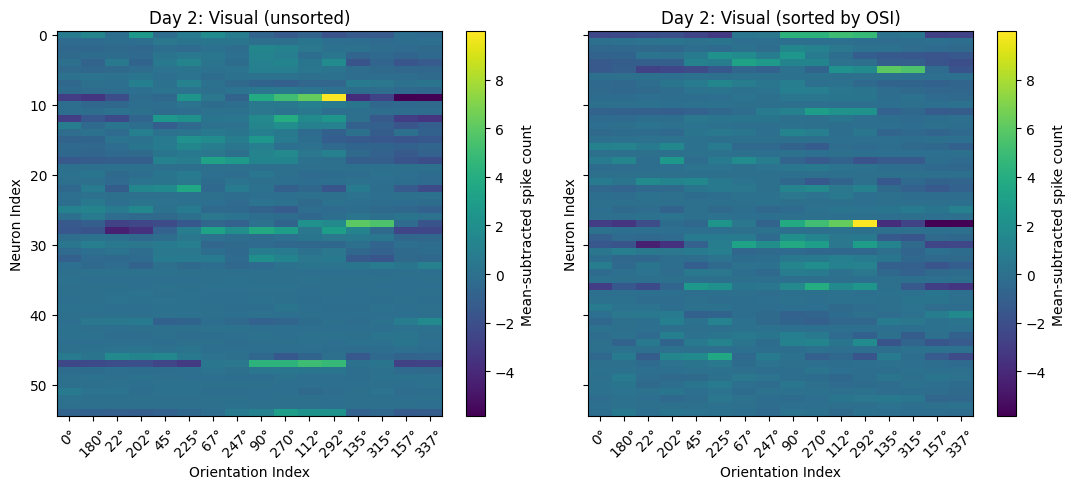

OSI range: 0.024 – 0.381  |  median: 0.104
Neuron order (high→low OSI): [47 45  2 15 18 27 36 16  5 48] ...


In [9]:
ori_order = [0, 8, 1, 9, 2, 10, 3, 11, 4, 12, 5, 13, 6, 14, 7, 15]

# Orientation selectivity index (OSI) via circular variance on doubled angles.
# OSI = |Σ_θ r(θ) exp(2i·θ)| / Σ_θ r(θ)
# Ranges [0, 1]: 0 = untuned, 1 = perfectly selective.
thetas = np.deg2rad(visual_orientation_degs2)  # (n_oris,)
r = avg_vis_responses_2.sum(axis=-1).T                           # (n_neurons, n_oris)
r_pos = np.clip(r, 0, None)                   # ensure non-negative before summing
complex_tuning = r_pos @ np.exp(2j * thetas)   # (n_neurons,)
osi = np.abs(complex_tuning) / (r_pos.sum(axis=1) + 1e-9)  # (n_neurons,)

neuron_order = np.argsort(osi)[::-1]           # descending OSI

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, order, label in [
    (axes[0], np.arange(avg_vis_responses_2.shape[1]), 'unsorted'),
    (axes[1], neuron_order,                        'sorted by OSI'),
]:
    xx = avg_vis_responses_2.sum(axis=-1)[ori_order][:, order]
    xx = xx - xx.mean(axis=0, keepdims=True)
    im = ax.imshow(xx.T, aspect='auto', cmap='viridis')
    ax.set_ylabel('Neuron Index')
    ax.set_xlabel('Orientation Index')
    ax.set_xticks(np.arange(len(visual_orientation_degs2)))
    ax.set_xticklabels([f'{int(o)}°' for o in visual_orientation_degs2[ori_order]], rotation=45)
    ax.set_title(f'Day 2: Visual ({label})')
    plt.colorbar(im, ax=ax, label='Mean-subtracted spike count')

plt.tight_layout()
plt.show()

print(f"OSI range: {osi.min():.3f} – {osi.max():.3f}  |  median: {np.median(osi):.3f}")
print(f"Neuron order (high→low OSI): {neuron_order[:10]} ...")


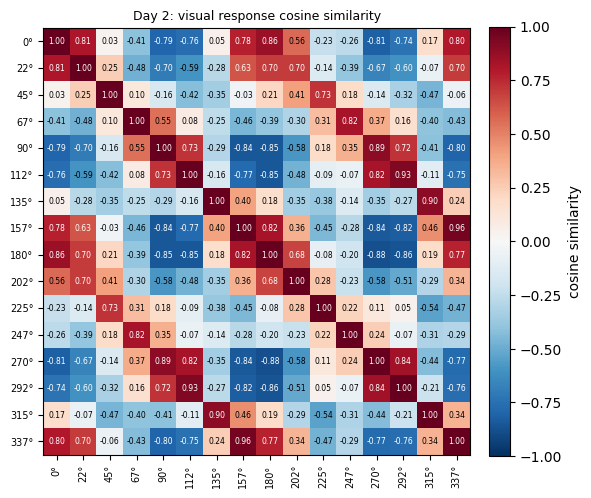

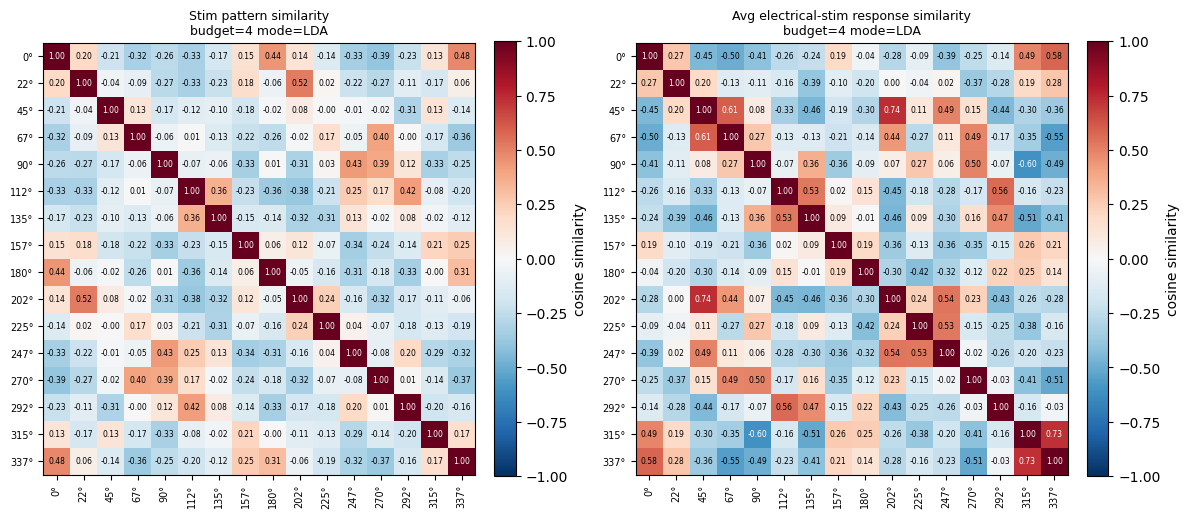

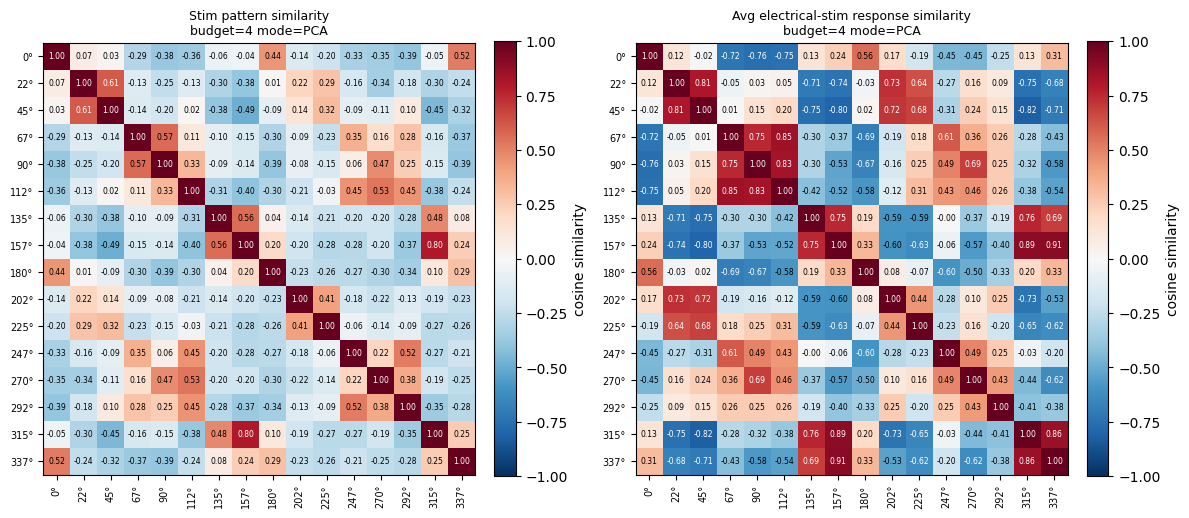

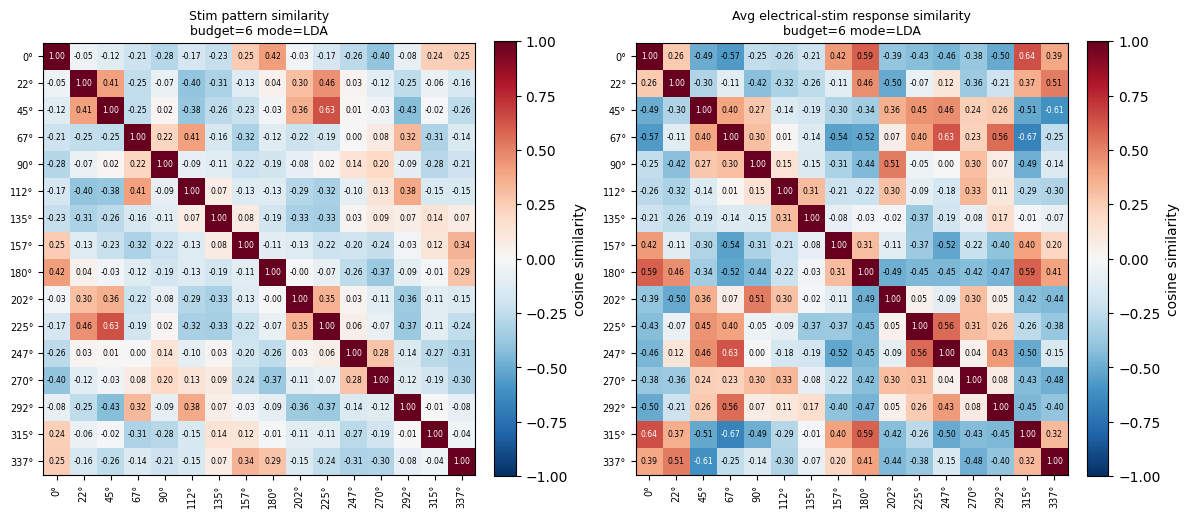

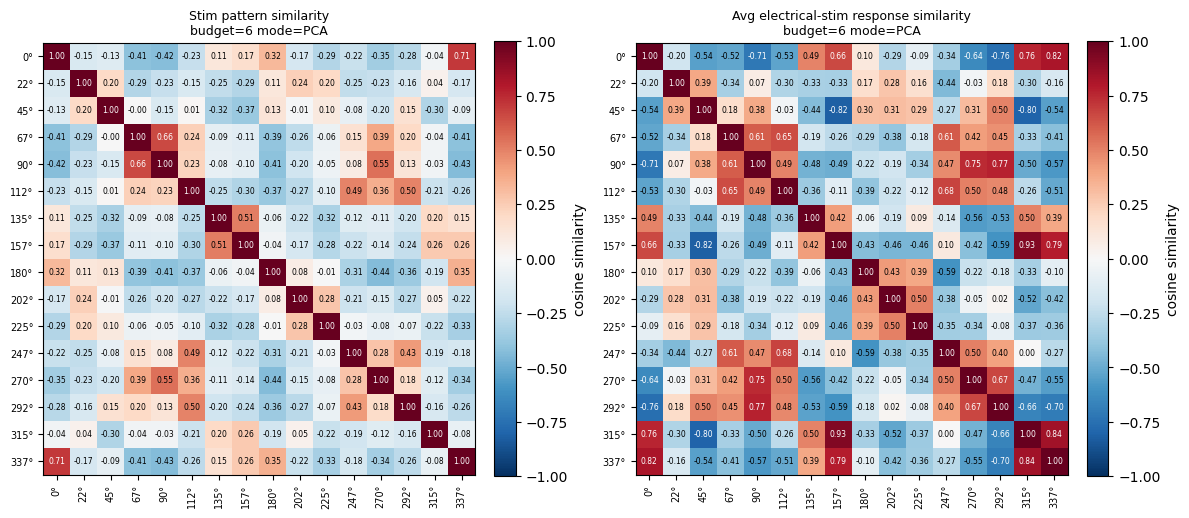

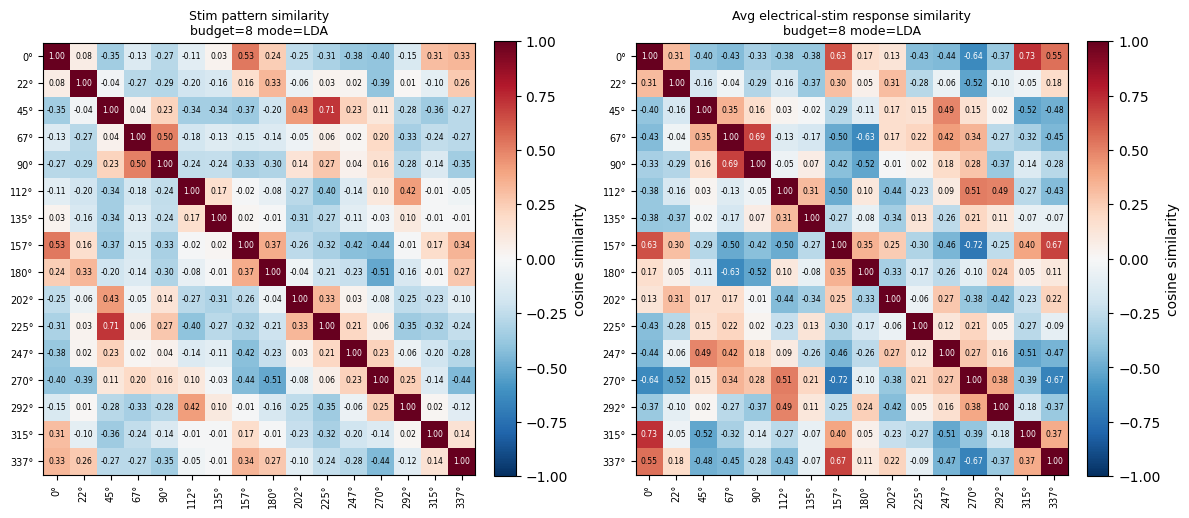

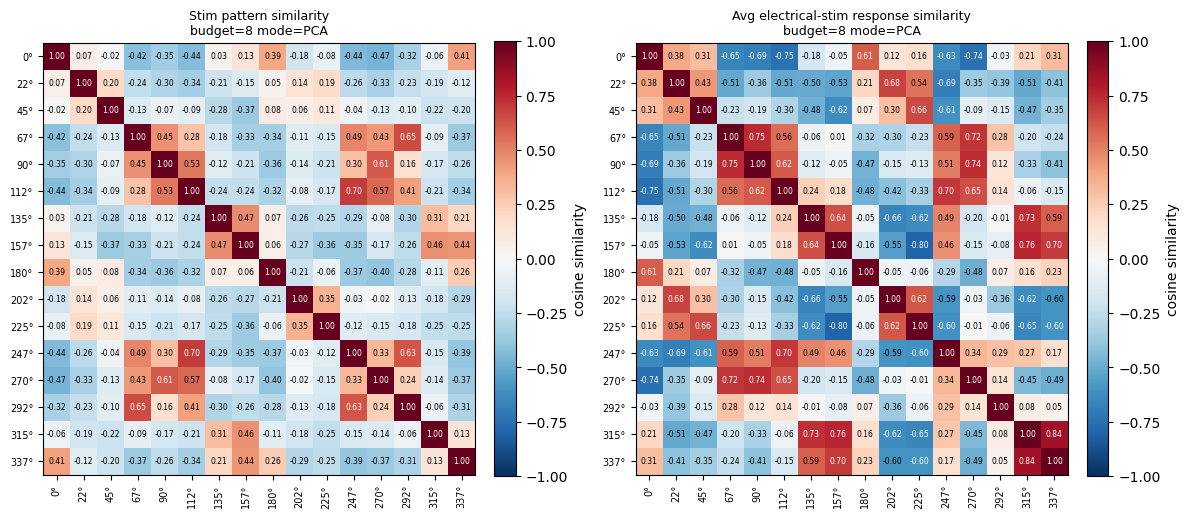

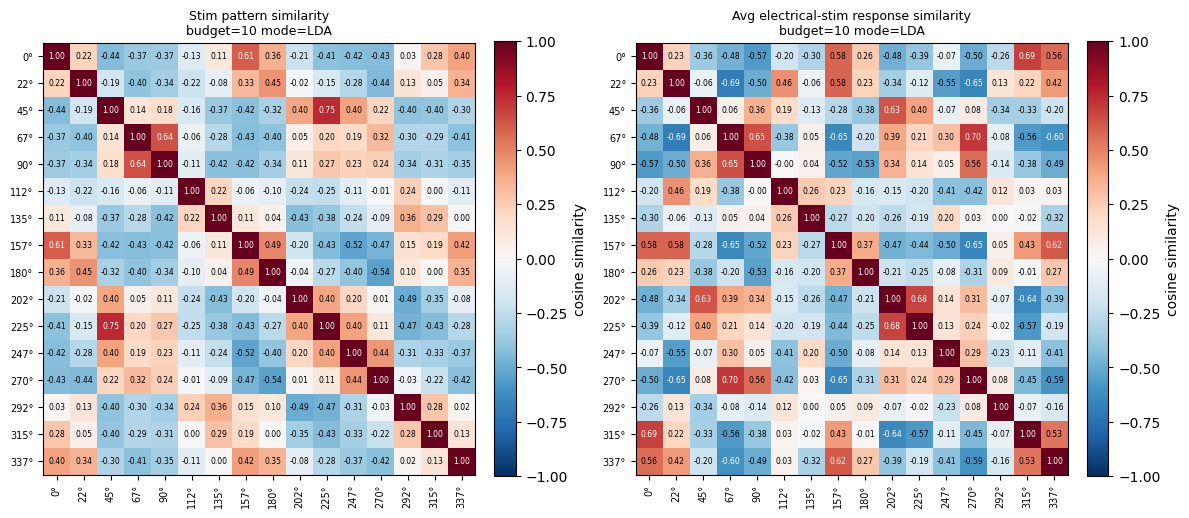

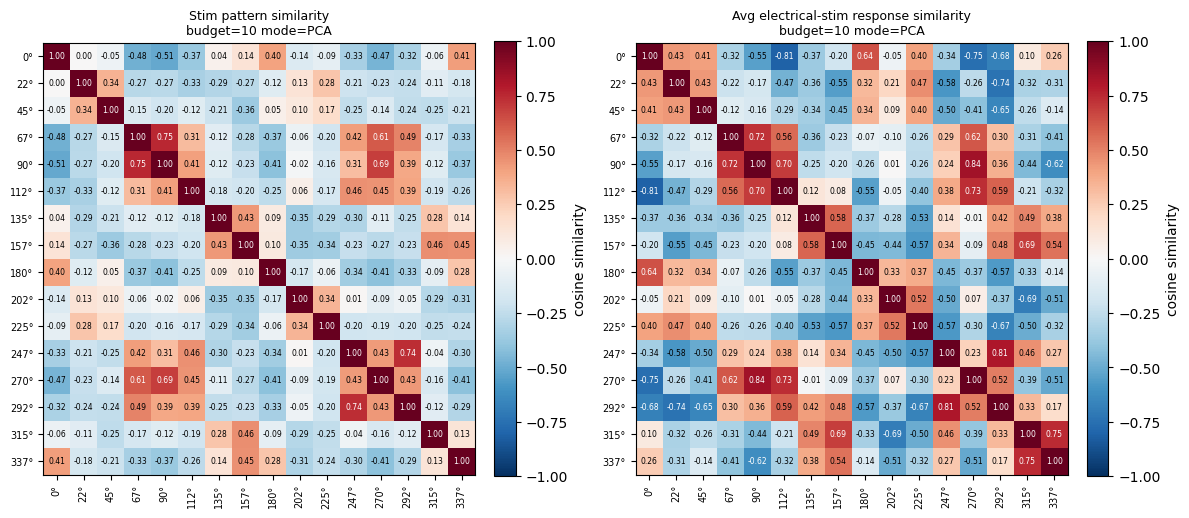

In [10]:
# ============================================================
# Pairwise cosine similarity across the 16 orientations, for:
#   1. Visual responses          (sum_responses_2, same for all budgets/modes)
#   2. Stim patterns delivered    (per budget/mode, from pattern_df_day2)
#   3. Average electrical-stim responses (stim_resp_mean, per budget/mode)
#
# Each matrix is (n_orient x n_orient), ordered by visual_orientation_degs2.
# ============================================================
from sklearn.preprocessing import normalize


def cosine_sim_matrix(X, center=True):
    """Row-wise cosine similarity matrix for X (n_rows, n_features)."""
    Xc = X - X.mean(axis=0, keepdims=True) if center else X
    Xn = normalize(Xc, norm='l2')
    return Xn @ Xn.T


def plot_sim_matrix(ax, sim, labels, title):
    n = len(labels)
    im = ax.imshow(sim, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'{int(o)}°' for o in labels], rotation=90, fontsize=7)
    ax.set_yticklabels([f'{int(o)}°' for o in labels], fontsize=7)
    ax.set_title(title, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=5.5, color='white' if abs(sim[i, j]) > 0.6 else 'black')
    return im


# --- 1. Visual response similarity (orientation x neuron, summed over time) ---
sim_visual = cosine_sim_matrix(avg_vis_responses_2.sum(axis=-1))  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = plot_sim_matrix(ax, sim_visual, visual_orientation_degs2,
                      'Day 2: visual response cosine similarity')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='cosine similarity')
plt.tight_layout()
plt.show()

# --- 2 & 3. Per (budget, mode): stim pattern + avg electrical response similarity ---
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df_day2['channel'].dropna().unique()))}
pattern_stims_day2 = build_pattern_stims_nominal(
    pattern_df_day2[pattern_df_day2['pattern_name'].isin(xref['pattern_name'])],
    channel_to_index, VIS_ORIENT_TIME)

for b_idx, budget in enumerate(budgets):
    for m_idx, mode_ in enumerate(modes):
        grp = (xref[(xref['source_budget'] == budget) & (xref['decomp_method'] == mode_)]
               .sort_values('target_orientation_deg'))
        stim_flat = np.stack([pattern_stims_day2[int(p)].ravel() for p in grp['pattern_name']], axis=0)
        sim_stim = cosine_sim_matrix(stim_flat)

        resp = stim_resp_avg_sum[b_idx, m_idx]  # (n_orient, n_neurons), already ordered by `oris`
        sim_resp = cosine_sim_matrix(resp)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
        im0 = plot_sim_matrix(axes[0], sim_stim, visual_orientation_degs2,
                               f'Stim pattern similarity\nbudget={budget} mode={mode_.upper()}')
        im1 = plot_sim_matrix(axes[1], sim_resp, visual_orientation_degs2,
                               f'Avg electrical-stim response similarity\nbudget={budget} mode={mode_.upper()}')
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='cosine similarity')
        plt.tight_layout()
        plt.savefig(f'data/icms_150_6_3_26/sim_matrices_budget_{budget}_mode_{mode_}.png', dpi=150)
        plt.show()


In [11]:
# Electrical-stim response ring: fit PCA on the per-orientation average stim
# responses themselves (no CIS axis) and project them into that 2-D space, to
# see whether the e-stim responses trace their own orientation ring. Individual
# deliveries are overlaid as low-alpha points (projected through the same basis).
def per_trial_stim_responses(pattern_name):
    """Per-delivery total spike counts for one pattern, summed over the
    VIS_ORIENT_TIME window. Returns (n_deliveries, n_neurons)."""
    onsets = deliveries[deliveries['pattern_name'] == pattern_name]['pattern_flag_start_timestamp'].values
    rows = []
    for t0 in onsets:
        seg = spikes_df_day2[(spikes_df_day2['timestamp'] >= t0) &
                             (spikes_df_day2['timestamp'] <  t0 + TRAJ_WIN_LEN)]
        v = np.zeros(d2_n_neurons)
        if not seg.empty:
            for nid, c in seg.groupby('neuron_id').size().items():
                if nid in d2_neuron_to_idx:
                    v[d2_neuron_to_idx[nid]] = c
        rows.append(v)
    return np.array(rows).reshape(-1, d2_n_neurons)   # (n_deliveries, n_neurons)

for b in budgets:
    for m in modes:
        print(f'Budget {b} Mode {m}:')
        if m != "pca":
            continue
        stim_resp = stim_resp_avg_sum[budgets.index(b), modes.index(m)]  # (n_orient, n_neurons)
        proj, coords, mean_vec = build_projection(stim_resp, mode="pca", include_cis=False)

        # Per-delivery points for each orientation, projected through the same basis.
        grp = (xref[(xref['source_budget'] == b) & (xref['decomp_method'] == m)]
               .sort_values('target_orientation_deg'))   # same orientation order as `oris`
        trial_pts, trial_doubled = [], []
        for _, row in grp.iterrows():
            per_trial = per_trial_stim_responses(int(row['pattern_name']))
            if len(per_trial) == 0:
                continue
            trial_pts.append(per_trial @ proj)
            trial_doubled.extend([(float(row['target_orientation_deg']) * 2) % 360] * len(per_trial))
        trial_coords  = np.vstack(trial_pts) if trial_pts else None
        trial_doubled = np.array(trial_doubled) if trial_pts else None

        fig = plot_ring(coords, visual_orientation_degs2,
                        f'Average Electrical Stim Responses (Budget {b} Mode {m.upper()})',
                        
                        ['PC1', 'PC2'],
                        trial_coords=trial_coords, trial_doubled=trial_doubled)
        fig.write_image(f'{day2_datadir}/stim_resp_pca_budget_{b}_mode_{m}.png', scale=2)
        fig.show()


Budget 4 Mode lda:
Budget 4 Mode pca:


Budget 6 Mode lda:
Budget 6 Mode pca:


Budget 8 Mode lda:
Budget 8 Mode pca:


Budget 10 Mode lda:
Budget 10 Mode pca:


Correlation matrix shape: (16, 16)


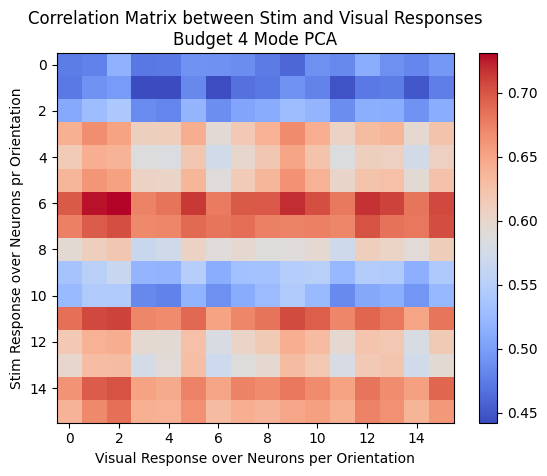

In [12]:
corr_budget = 4
corr_mode = analysis_mode

stim_resp = stim_resp_avg_sum[budgets.index(corr_budget), modes.index(corr_mode)] / stim_resp_avg_sum[budgets.index(corr_budget), modes.index(corr_mode)].max()  # (n_orient, n_neurons)
visual_resp2 = avg_vis_responses_2.sum(axis=-1) / avg_vis_responses_2.sum(axis=-1).max()  # (n_orient, n_neurons)
# Correlation of each stim response with each visual response, across neurons.
# result is a neurons x neurons matrix of how similarly the stim and visual responses are tuned across orientations for each neuron
full_matrix = np.corrcoef(stim_resp, visual_resp2)     # Result: (32, 32)
correlation_matrix = full_matrix[:16, 16:]             # Target block: (16, 16)
print (f'Correlation matrix shape: {correlation_matrix.shape}')
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xlabel('Visual Response over Neurons per Orientation')
plt.ylabel('Stim Response over Neurons pr Orientation')
plt.title(f'Correlation Matrix between Stim and Visual Responses\nBudget {corr_budget} Mode {corr_mode.upper()}')
plt.show()

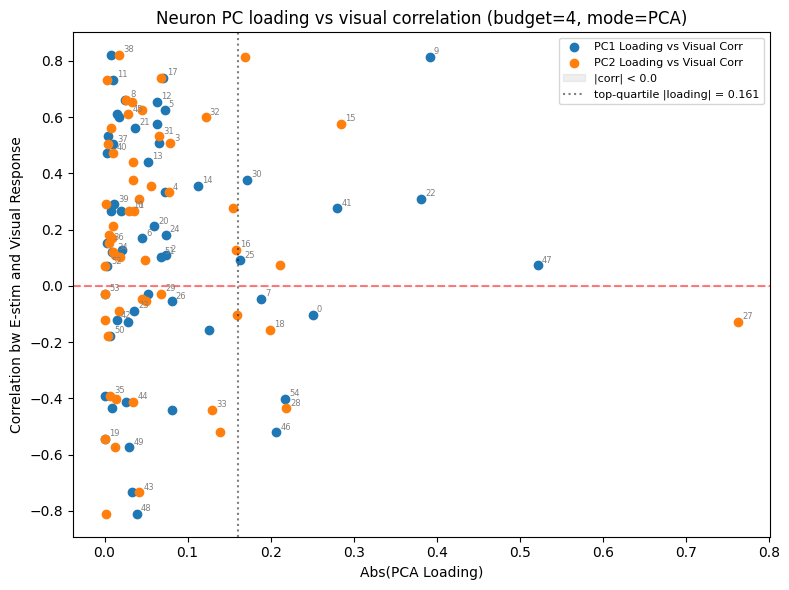

High-loading / low-visual-correlation neurons (|loading| >= 0.161, |corr| < 0.0):
neuron   |PC1|   |PC2|  max|load|  visual_corr
  (none met both thresholds)


In [13]:
corr_thresh = 0.0                                      # |corr| below this = "uncorrelated"

proj_loadings, _, mean_vec = build_projection(avg_vis_responses_2.sum(axis=-1), mode="pca", include_cis=True)  # (n_neurons, 2)



# Get the PCA loadings for each neuron on PC1 and PC2
visual_pca_loadings = proj_loadings[:, 1:3]  # (n_neurons, 2)
# Get the correlation of each neuron with the visual responses across orientations
neuron_stim_visual_corr = np.array([np.corrcoef(stim_resp[:, i], visual_resp2[:, i])[0, 1] for i in range(stim_resp.shape[1])])


max_loading = np.abs(visual_pca_loadings).max(axis=1)          # strongest of PC1/PC2 per neuron
load_thresh = np.nanpercentile(max_loading, 75)         # top-quartile loaders
flagged = np.where((max_loading >= load_thresh) &
                   (np.abs(neuron_stim_visual_corr) < corr_thresh))[0]

# Now we can plot the PCA loadings against the visual correlation for each neuron
plt.figure(figsize=(8, 6))
plt.scatter(np.abs(visual_pca_loadings[:, 0]), neuron_stim_visual_corr, label='PC1 Loading vs Visual Corr')
plt.scatter(np.abs(visual_pca_loadings[:, 1]), neuron_stim_visual_corr, label='PC2 Loading vs Visual Corr')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.axhspan(-corr_thresh, corr_thresh, color='gray', alpha=0.12,
            label=f'|corr| < {corr_thresh}')
plt.axvline(x=load_thresh, color='k', linestyle=':', alpha=0.5,
            label=f'top-quartile |loading| = {load_thresh:.3f}')

# Label every neuron at its strongest-PC point so each can be identified; flagged
# (high-loading / low-corr) neurons are emphasised in red and bold.
for i in range(visual_pca_loadings.shape[0]):
    x = max_loading[i]                       # plot the label at the stronger PC loading
    y = neuron_stim_visual_corr[i]
    is_flagged = i in flagged
    plt.annotate(str(i), (x, y),
                 textcoords='offset points', xytext=(3, 2),
                 fontsize=8 if is_flagged else 6,
                 color='red' if is_flagged else 'gray',
                 fontweight='bold' if is_flagged else 'normal',
                 zorder=5 if is_flagged else 3)

plt.xlabel('Abs(PCA Loading)')
plt.ylabel('Correlation bw E-stim and Visual Response')
plt.title(f'Neuron PC loading vs visual correlation '
          f'(budget={corr_budget}, mode={corr_mode.upper()})')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Report the flagged neurons: strong PC driver, weak visual tuning.
order = flagged[np.argsort(max_loading[flagged])[::-1]]   # strongest loaders first
print(f'High-loading / low-visual-correlation neurons '
      f'(|loading| >= {load_thresh:.3f}, |corr| < {corr_thresh}):')
print(f'{"neuron":>6} {"|PC1|":>7} {"|PC2|":>7} {"max|load|":>10} {"visual_corr":>12}')
for i in order:
    print(f'{i:>6} {abs(visual_pca_loadings[i,0]):>7.3f} {abs(visual_pca_loadings[i,1]):>7.3f} '
          f'{max_loading[i]:>10.3f} {neuron_stim_visual_corr[i]:>12.3f}')
if len(order) == 0:
    print('  (none met both thresholds)')


In [14]:
neurons_to_remove = flagged
# recompute visual rings and stim response overlaps without the flagged neurons

visual_rings_filtered = np.delete(avg_vis_responses_2, neurons_to_remove, axis=1)
stim_resp_filtered = np.delete(stim_resp, neurons_to_remove, axis=1)

# Build a 3-axis QR projection [CIS, PC1, PC2] of the filtered visual responses.
# The first axis (CIS = population mean direction) absorbs the overall offset, so
# subtracting mean_filt before projecting (same convention as build_projection's
# own (X - mean_vec) @ proj) puts both visual and stim points in the same
# mean-centered frame -- so stim and visual become comparable.
proj_filt, coords_filt, mean_filt = build_projection(visual_rings_filtered.sum(axis=-1),
                                          mode="pca", include_cis=True)   # (n_neurons, 3)
fig = plot_ring(coords_filt[:, 1:], visual_orientation_degs2,             # drop CIS -> PC1/PC2 ring
                f'Visual Ring (filtered, budget={corr_budget} mode={corr_mode.upper()})',
                ['PC1', 'PC2'])

# Stim responses projected through the SAME 3-axis basis, mean-subtracted the
# same way as the visual ring coords, keeping PC1/PC2 only.
# (i is 0-indexed, so stim_pts[i] lines up with visual_orientation_degs2[i])
stim_pts = []
for i, ori_deg in enumerate(visual_orientation_degs2):
    proj_stim = (stim_resp_filtered[i, :] - mean_filt) @ proj_filt   # (1,3) -> [CIS, PC1, PC2]
    stim_pts.append(proj_stim[0, 1:])                                # keep PC1/PC2
stim_pts = np.array(stim_pts)

# Diamonds, colored by orientation with the SAME doubled-angle HSV mapping the
# visual ring uses -> matching orientation = matching color, so each stim diamond
# can be compared against its same-colored visual circle.
stim_doubled = (np.array(visual_orientation_degs2) * 2) % 360
fig.add_scatter(
    x=stim_pts[:, 0], y=stim_pts[:, 1],
    mode='markers+text', name='Stim Responses',
    text=[f'{int(o)}°' for o in visual_orientation_degs2], textposition='bottom center',
    marker=dict(symbol='diamond', size=11, color=stim_doubled, colorscale='HSV',
                cmin=0, cmax=360, line=dict(color='black', width=1)),
)

fig.show()


## Oracle trials across days (within- and across-day drift)

The 50 oracle patterns (each repeated ~20x) were delivered on **both** days. Their
`pattern_name` namespaces are not guaranteed to line up, and the generated day-2
target patterns (those in the xref) are *not* oracles, so we identify oracles by
their actual stimulus content: each pattern is a sequence of steps, and each step
fires a set of `(channel, delay_mode)` pairs. We encode that sequence into a
canonical signature, match day-1 to day-2 oracles by identical signature, and build
a long-format **trial table** (`oracle_id, day, trial, pattern_name, onset_ts`).

This cell builds only the join table — one row per delivery. Response extraction
(per-trial spike-count vectors, per-day neuron indexing) is a later step. The table
supports **within-day drift** (sort by `trial` within a `(oracle_id, day)`) and
**across-day drift** (compare a matched `oracle_id` between days).

In [15]:
# ============================================================
# Build the cross-day oracle trial table.
#
#   1. pattern_signature(): canonical content hash of a pattern's step sequence.
#      For each step_index, take the sorted set of (channel, delay_mode) pairs;
#      the pattern is the tuple of those per-step sets. Stable across deliveries
#      (same pattern -> same signature) and unique per distinct pattern.
#   2. Oracle = is_oracle AND pattern_name not in the xref (xref patterns are the
#      generated day-2 targets, deliberately repeated but not "oracles").
#   3. Match day-1 <-> day-2 oracles by identical signature -> oracle_id.
#   4. Emit one row per delivery (long format).
# ============================================================
xref_names = set(pd.read_csv('data/icms_150_6_2_26/generated_patterns_day2_6_3_26.csv')
                 ['pattern_name'].astype(int))


def pattern_signature(pattern_df, pattern_name):
    """Canonical content signature of a pattern: a tuple over steps of the sorted
    (channel, delay_mode) pairs fired at that step. Uses one delivery (all
    deliveries of an oracle share the same stimulus)."""
    ti = pattern_df.loc[pattern_df['pattern_name'] == pattern_name,
                        'pattern_timing_index'].iloc[0]
    sub = pattern_df[pattern_df['pattern_timing_index'] == ti]
    steps = []
    for si, g in sub.groupby('step_index'):
        pairs = tuple(sorted(map(tuple, g[['channel', 'delay_mode']].values.tolist())))
        steps.append((int(si), pairs))
    return tuple(steps)


def oracle_signatures(pattern_df):
    """{pattern_name -> signature} for the true oracles of one day (is_oracle and
    not an xref-generated pattern)."""
    names = sorted(n for n in pattern_df.loc[pattern_df['is_oracle'], 'pattern_name'].unique()
                   if int(n) not in xref_names)
    return {n: pattern_signature(pattern_df, n) for n in names}


sig_day1 = oracle_signatures(pattern_df_day1)
sig_day2 = oracle_signatures(pattern_df_day2)

# Match by signature. oracle_id is assigned in day-1 pattern_name order.
sig_to_day2 = {s: n for n, s in sig_day2.items()}
oracle_xref_rows = []
for oid, (d1_name, sig) in enumerate(sorted(sig_day1.items())):
    d2_name = sig_to_day2.get(sig)
    if d2_name is None:
        print(f'[warn] day-1 oracle {d1_name} has no signature match on day 2')
        continue
    oracle_xref_rows.append({'oracle_id': oid,
                             'day1_pattern_name': d1_name,
                             'day2_pattern_name': d2_name})
oracle_xref = pd.DataFrame(oracle_xref_rows)
print(f'Matched {len(oracle_xref)} oracles across days '
      f'(day1 oracles: {len(sig_day1)}, day2 oracles: {len(sig_day2)})')


def _day_trials(pattern_df, day, name_col):
    """Long-format delivery rows for one day's matched oracles.
    One row per (oracle_id, trial): oracle_id, day, trial, pattern_name, onset_ts."""
    keep = (pattern_df[['pattern_name', 'trial', 'pattern_flag_start_timestamp']]
            .drop_duplicates())
    keep = keep[keep['pattern_name'].isin(oracle_xref[name_col])]
    keep = keep.merge(oracle_xref[['oracle_id', name_col]],
                      left_on='pattern_name', right_on=name_col, how='left')
    out = keep[['oracle_id', 'pattern_name', 'trial', 'pattern_flag_start_timestamp']].copy()
    out = out.rename(columns={'trial': 'trial',
                              'pattern_flag_start_timestamp': 'onset_ts'})
    out['day'] = day
    out['trial'] = out['trial'].astype(int)
    return out[['oracle_id', 'day', 'trial', 'pattern_name', 'onset_ts']]


oracle_trials = pd.concat([
    _day_trials(pattern_df_day1, 1, 'day1_pattern_name'),
    _day_trials(pattern_df_day2, 2, 'day2_pattern_name'),
], ignore_index=True)
oracle_trials = oracle_trials.sort_values(['oracle_id', 'day', 'trial']).reset_index(drop=True)

print(f'oracle_trials: {len(oracle_trials)} delivery rows '
      f'({oracle_trials["oracle_id"].nunique()} oracles x ~20 trials x 2 days)')
print('trials per (oracle, day):',
      oracle_trials.groupby(['oracle_id', 'day']).size().describe()[['min', 'max']].to_dict())
oracle_trials.head(10)


Matched 50 oracles across days (day1 oracles: 50, day2 oracles: 50)
oracle_trials: 1980 delivery rows (50 oracles x ~20 trials x 2 days)
trials per (oracle, day): {'min': 18.0, 'max': 20.0}


,oracle_id,day,trial,pattern_name,onset_ts
0,0,1,1,3001,56637344
1,0,1,2,3001,69264201
2,0,1,3,3001,88575571
3,0,1,4,3001,89862384
4,0,1,5,3001,105438161
5,0,1,6,3001,106421330
6,0,1,7,3001,126531071
7,0,1,8,3001,141686417
8,0,1,9,3001,142915004
9,0,1,10,3001,148487484


<Figure size 1000x600 with 0 Axes>

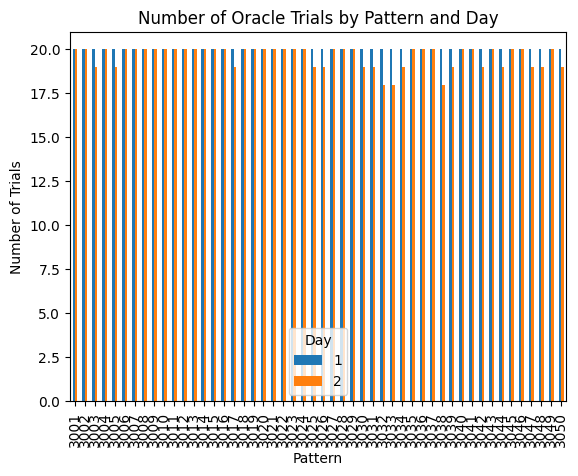

In [16]:
plt.figure(figsize=(10, 6))
oracle_trials.groupby(['pattern_name', 'day']).size().unstack(fill_value=0).plot(kind='bar', stacked=False)
plt.title("Number of Oracle Trials by Pattern and Day")
plt.xlabel("Pattern")
plt.ylabel("Number of Trials")
plt.legend(title="Day")
plt.show()

In [17]:
# ============================================================
# Attach a per-delivery response vector to each oracle trial.
#
#   * Summed spike counts over an ORACLE_WIN_MS window after each onset_ts.
#   * Per-day INDEPENDENT neuron indexing: each day uses its own sorted
#     neuron_id set, so the vectors have different lengths across days. This
#     is fine for within-day drift; across-day comparison must first restrict
#     to the common neuron set (see common_neuron_ids / aligned_response below).
#
# Results:
#   resp_day[day]       -> (n_trials_day, n_neurons_day) matrix, row-aligned to
#                          oracle_trials[oracle_trials.day == day] (post-sort).
#   neuron_ids_day[day] -> the sorted neuron_id ordering for that day's columns.
#   oracle_trials['response'] -> object column, each cell an (n_neurons_day,) vec.
# ============================================================
ORACLE_WIN_MS = VIS_ORIENT_TIME            # 600 ms, same window as the stim-response cells
ORACLE_WIN_LEN = ORACLE_WIN_MS * SAMPLES_PER_MS

spikes_by_day = {1: spikes_df_day1, 2: spikes_df_day2}
neuron_ids_day = {d: np.sort(s['neuron_id'].unique()) for d, s in spikes_by_day.items()}
neuron_to_idx_day = {d: {n: i for i, n in enumerate(ids)} for d, ids in neuron_ids_day.items()}


def summed_response(spikes, neuron_to_idx, t0, win_len):
    """(n_neurons,) total spike counts in [t0, t0+win_len)."""
    n_neurons = len(neuron_to_idx)
    seg = spikes[(spikes['timestamp'] >= t0) & (spikes['timestamp'] < t0 + win_len)]
    v = np.zeros(n_neurons)
    if not seg.empty:
        for nid, c in seg.groupby('neuron_id').size().items():
            if nid in neuron_to_idx:
                v[neuron_to_idx[nid]] = c
    return v


# Build per-delivery response vectors, row-aligned to the sorted oracle_trials.
responses = []
resp_day = {1: [], 2: []}
for _, row in oracle_trials.iterrows():
    d = int(row['day'])
    v = summed_response(spikes_by_day[d], neuron_to_idx_day[d],
                        int(row['onset_ts']), ORACLE_WIN_LEN)
    responses.append(v)
    resp_day[d].append(v)

oracle_trials['response'] = responses
resp_day = {d: np.array(rows) for d, rows in resp_day.items()}

print(f'Window: {ORACLE_WIN_MS} ms = {ORACLE_WIN_LEN} samples')
for d in (1, 2):
    print(f'  day {d}: resp_day[{d}] shape {resp_day[d].shape}  '
          f'({len(neuron_ids_day[d])} neurons)  '
          f'mean spikes/trial {resp_day[d].sum(axis=1).mean():.1f}')



Window: 600 ms = 18000 samples
  day 1: resp_day[1] shape (1000, 63)  (63 neurons)  mean spikes/trial 203.2
  day 2: resp_day[2] shape (980, 55)  (55 neurons)  mean spikes/trial 144.3


In [18]:
# ============================================================
# Within-session stim-response DRIFT: first half vs second half.
#
# Question: does the population response to a FIXED stimulus change over the
# course of a session? Using oracle patterns (same stim repeated ~20x/day) so
# any change is neural, not stimulus identity.
#
#   * Split each oracle pattern's deliveries at the SESSION midpoint in
#     wall-clock time ((min+max onset_ts)/2 over that day's oracle trials):
#     deliveries before the midpoint = "first half", after = "second half".
#   * Average each half's response vectors per pattern.
#   * Project both halves into that DAY's VISUAL PC space (CIS+PC1/PC2 via
#     build_projection on the day's per-orientation visual averages, restricted
#     to the SAME neuron set used for the oracle responses), then plot PC1/PC2
#     (CIS dropped). An arrow from first->second half per pattern shows drift.
# ============================================================
import plotly.graph_objects as go

DRIFT_DAY = 2   # <-- day to analyze (start with 1)

# --- responses + onsets for this day's oracle deliveries (row-aligned) -------
day_mask   = oracle_trials['day'] == DRIFT_DAY
day_tr     = oracle_trials[day_mask].reset_index(drop=True)
day_resp   = resp_day[DRIFT_DAY]                       # (n_trials_day, n_neurons_day), same row order
assert len(day_tr) == len(day_resp), "oracle_trials/resp_day row mismatch for this day"
neuron_ids = neuron_ids_day[DRIFT_DAY]                 # neuron axis of day_resp columns
nidx       = neuron_to_idx_day[DRIFT_DAY]
n_neurons  = len(neuron_ids)

# --- session midpoint in wall-clock time -------------------------------------
onsets       = day_tr['onset_ts'].astype(np.int64).values
session_mid  = (onsets.min() + onsets.max()) / 2.0
first_half   = onsets < session_mid                    # boolean over deliveries

# --- per-pattern average response in each half -------------------------------
patterns = sorted(day_tr['pattern_name'].unique())
first_avgs, second_avgs, kept_patterns = [], [], []
for p in patterns:
    pm = (day_tr['pattern_name'] == p).values
    f  = pm & first_half
    s  = pm & ~first_half
    if f.sum() == 0 or s.sum() == 0:
        print(f'[skip] pattern {p}: deliveries all in one half (first={f.sum()}, second={s.sum()})')
        continue
    first_avgs.append(day_resp[f].mean(axis=0))
    second_avgs.append(day_resp[s].mean(axis=0))
    kept_patterns.append(p)
first_avgs  = np.array(first_avgs)                     # (n_patterns, n_neurons)
second_avgs = np.array(second_avgs)
print(f'day {DRIFT_DAY}: {len(kept_patterns)} oracle patterns with deliveries in both halves '
      f'(session split at ts={session_mid:.0f}; '
      f'{first_half.sum()} first-half / {(~first_half).sum()} second-half deliveries)')

# --- visual PC space for THIS day, on the SAME neuron set as the responses ----
# Per-orientation visual averages restricted to `neuron_ids` so the projection's
# neuron axis lines up with first_avgs/second_avgs columns.
vis_spikes = {1: visual_spikes_1, 2: visual_spikes_2}[DRIFT_DAY]
vis_tdf    = {1: visual_trial_df1, 2: visual_trial_df2}[DRIFT_DAY]
oris       = {1: visual_orientation_degs1, 2: visual_orientation_degs2}[DRIFT_DAY]

vis_avg = np.zeros((len(oris), n_neurons))
for o_i, ori in enumerate(oris):
    t0s = vis_tdf[vis_tdf['orientation'] == ori]['timestamp'].values[:N_VIS_TRIALS]
    for t0 in t0s:
        seg = vis_spikes[(vis_spikes['timestamp'] >= t0) &
                         (vis_spikes['timestamp'] <  t0 + WINDOW_LEN)]
        if seg.empty:
            continue
        for nid, c in seg.groupby('neuron_id').size().items():
            if nid in nidx:
                vis_avg[o_i, nidx[nid]] += c
    vis_avg[o_i] /= max(len(t0s), 1)

proj, vis_coords, vis_mean = build_projection(vis_avg, mode="pca", include_cis=True)  # (n_neurons, 3)

def to_pc(M):
    """(k, n_neurons) -> PC1/PC2 in the day's visual space (CIS dropped)."""
    return ((M - vis_mean) @ proj)[:, 1:]

first_pc  = to_pc(first_avgs)
second_pc = to_pc(second_avgs)

# --- plot: visual ring + first/second-half stim points + drift arrows --------
fig = plot_ring(vis_coords[:, 1:], oris,
                f'Within-session stim drift, day {DRIFT_DAY} (oracle patterns)',
                ['PC1', 'PC2'])

fig.add_scatter(x=first_pc[:, 0], y=first_pc[:, 1], mode='markers',
                name='First half', marker=dict(symbol='circle', size=9,
                color='rgba(30,30,200,0.8)', line=dict(color='black', width=1)))
fig.add_scatter(x=second_pc[:, 0], y=second_pc[:, 1], mode='markers',
                name='Second half', marker=dict(symbol='diamond', size=10,
                color='rgba(200,30,30,0.8)', line=dict(color='black', width=1)))

# drift arrows first -> second per pattern (blue->red)
for a, b in zip(first_pc, second_pc):
    fig.add_annotation(x=b[0], y=b[1], ax=a[0], ay=a[1],
                       xref='x', yref='y', axref='x', ayref='y',
                       showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1,
                       arrowcolor='rgba(120,120,120,0.6)')

# mean drift vector across patterns
mean_drift = (second_pc - first_pc).mean(axis=0)
mean_mag   = np.linalg.norm(second_pc - first_pc, axis=1).mean()
print(f'mean first->second drift vector (PC1,PC2): ({mean_drift[0]:.2f}, {mean_drift[1]:.2f}); '
      f'mean per-pattern drift magnitude: {mean_mag:.2f}')

fig.show()


day 2: 50 oracle patterns with deliveries in both halves (session split at ts=162508448; 493 first-half / 487 second-half deliveries)
mean first->second drift vector (PC1,PC2): (0.55, -0.04); mean per-pattern drift magnitude: 1.08


In [19]:
# Day 1 vs. Day 2: oracle stim averages projected into each day's VISUAL PCA space.
# Backdrop = that day's visual ring (per-orientation responses, colored by orientation)
# via plot_ring; overlay = the per-oracle trial-averaged stim responses (black diamonds).
# Day 2 also overlays the TARGETED (generated, orientation-labeled) stim averages,
# colored by orientation so they align with the visual ring.
#
# PLOTMODE = '2d' -> PC1/PC2 plane (drop CIS)
# PLOTMODE = '3d' -> CIS/PC1/PC2
PLOTMODE = '3d'    # '2d' or '3d'
corr_budget = 8
day1_proj, day1_vis_mean = make_ring(avg_vis_responses_1, visual_orientation_degs1, visual_trial_df1, visual_spikes_1, mode=analysis_mode, include_CIS=True)
day2_proj, day2_vis_mean = make_ring(avg_vis_responses_2, visual_orientation_degs2, visual_trial_df2, visual_spikes_2, mode=analysis_mode, include_CIS=True)
oracle_day1_avgs = {}
oracle_day2_avgs = {}
for pattern in oracle_trials['pattern_name'].unique():
    d1 = oracle_trials[(oracle_trials['pattern_name'] == pattern) & (oracle_trials['day'] == 1)]
    d2 = oracle_trials[(oracle_trials['pattern_name'] == pattern) & (oracle_trials['day'] == 2)]
    oracle_day1_avgs[pattern] = np.stack(d1['response'].values).mean(axis=0)   # (n_neurons_day1,)
    oracle_day2_avgs[pattern] = np.stack(d2['response'].values).mean(axis=0)   # (n_neurons_day2,)

oracle_day1_avgs = pd.DataFrame.from_dict(oracle_day1_avgs, orient='index')
oracle_day2_avgs = pd.DataFrame.from_dict(oracle_day2_avgs, orient='index')

# Project oracle stim averages onto each day's visual PCs (same basis as that day's ring).
# make_ring now builds day*_proj / day*_vis_mean on the 600 ms (VIS_ORIENT_TIME) scale,
# the same window the oracle/targeted averages are summed over, so no rescale is needed here.
oracle_day1_visproj = (oracle_day1_avgs.values - day1_vis_mean) @ day1_proj   # (n_oracles, 3) [CIS, PC1, PC2]
oracle_day2_visproj = (oracle_day2_avgs.values - day2_vis_mean) @ day2_proj

# Targeted (generated) day-2 stim averages for one (budget, mode): (n_orient, n_neurons_day2).
# Mean-subtracted with day2_vis_mean only, same convention as the oracle projections
# above and as build_projection's (X - mean_vec) @ proj.
target_budget = corr_budget if 'corr_budget' in globals() else budgets[0]
target_mode   = analysis_mode
target_stim_avg   = stim_resp_avg_sum[budgets.index(target_budget), modes.index(target_mode)]
target_stim_proj  = (target_stim_avg - day2_vis_mean) @ day2_proj                       # (n_orient, 3)
target_doubled    = (np.array(visual_orientation_degs2) * 2) % 360     # orientation colors


# Column slice + axis labels for the chosen plot mode.
# 3d -> all of [CIS, PC1, PC2]; 2d -> drop CIS, keep [PC1, PC2].
_cols   = slice(0, 3) if PLOTMODE == '3d' else slice(1, 3)
_labels = ['CIS', 'PC1', 'PC2'] if PLOTMODE == '3d' else ['PC1', 'PC2']


def _overlay(fig, pts, **scatter_kw):
    """Add a 2- or 3-D scatter overlay matching PLOTMODE (pts already sliced)."""
    if PLOTMODE == '3d':
        fig.add_scatter3d(x=pts[:, 0], y=pts[:, 1], z=pts[:, 2], **scatter_kw)
    else:
        fig.add_scatter(x=pts[:, 0], y=pts[:, 1], **scatter_kw)


def oracle_ring(avg_vis_responses, day_proj, day_mean, orientation_degs, oracle_proj, title):
    """Visual ring (per-orientation) as backdrop + oracle stim averages overlaid.
    vis_coords is mean-subtracted the same way as oracle_proj/build_projection's
    own (X - mean_vec) @ proj, so backdrop and overlay share the same centering."""
    # day_mean/day_proj are on the 600 ms scale (make_ring), so rescale the
    # 500 ms visual responses by VIS_ORIENT_TIME/STIM_MS before centering.
    vis_coords = (avg_vis_responses.sum(axis=-1) * (VIS_ORIENT_TIME / STIM_MS) - day_mean) @ day_proj   # (n_orient, 3)
    fig = plot_ring(vis_coords[:, _cols], orientation_degs, title, _labels)
    _overlay(fig, oracle_proj[:, _cols],
             mode='markers', name='Oracle stim average',
             marker=dict(symbol='diamond', size=9, color='black',
                         line=dict(color='white', width=0.5)))
    return fig


fig1 = oracle_ring(avg_vis_responses_1, day1_proj, day1_vis_mean, visual_orientation_degs1,
            oracle_day1_visproj, 'Day 1: oracle stim avgs in visual PCA space')
fig1.show()

fig2 = oracle_ring(avg_vis_responses_2, day2_proj, day2_vis_mean, visual_orientation_degs2,
                   oracle_day2_visproj, 'Day 2: oracle + targeted stim avgs in visual PCA space')
_overlay(fig2, target_stim_proj[:, _cols],
         mode='markers+text', name=f'Targeted stim avg (b={target_budget}, {target_mode.upper()})',
         text=[f'{int(o)}°' for o in visual_orientation_degs2], textposition='bottom center',
         marker=dict(symbol='square', size=11, color=target_doubled, colorscale='HSV',
                     cmin=0, cmax=360, line=dict(color='black', width=1)))
fig2.show()


PCA explained variance ratio: [0.45266503 0.21691976]


PCA explained variance ratio: [0.61187195 0.16925445]


In [20]:
# ============================================================
# Trial-count convergence of the visual ring (plotly, 2D or 3D).
#
# For each sample size n in N_LIST, draw N_SHUFF random subsets of n trials per
# orientation, average each subset into a per-orientation response, and project
# it into the FIXED day-1 visual basis (day1_vis_proj / day1_vis_mean from
# cell 5). Averaging the shuffles gives a "true" mean ring for that n.
#
# Each n is one color; the orientations of a given n are connected (in
# orientation order) by a faint black line so each ring reads as a ring.
# day1_vis_proj is 3D when cell 5 ran with include_CIS=True (axes = CIS, PC1,
# PC2) and 2D otherwise -- the plot follows whatever basis was built.
# ============================================================
import plotly.graph_objects as go

N_LIST  = [5, 10, 30, 100]
N_SHUFF = 20
RNG     = np.random.default_rng(0)

# --- day-1 data + its fitted visual ring basis -------------------------
_spikes      = visual_spikes_1
_trial_df    = visual_trial_df1
_orient_degs = visual_orientation_degs1
_proj        = day1_vis_proj          # (n_neurons, 3) if CIS else (n_neurons, 2)
_mean        = day1_vis_mean          # (1, n_neurons), subtracted before projection
is3d         = _proj.shape[1] == 3

n_neurons     = _proj.shape[0]
neuron_to_idx = {nid: i for i, nid in enumerate(np.sort(_spikes['neuron_id'].unique()))}

# Per-trial spike-count vectors over the full 500 ms stim window, by orientation.
all_counts, all_labels = trial_counts(_spikes, _trial_df, _orient_degs,
                                       neuron_to_idx, STIM_MS, n_neurons,
                                       n_trials=N_VIS_TRIALS)
counts_by_ori = {ori: all_counts[all_labels == ori] for ori in _orient_degs}

# Connecting-line order: walk orientations by doubled angle, then close the loop.
doubled    = (np.array(_orient_degs).astype(int) * 2) % 360
ring_order = np.argsort(doubled)
ring_order = np.append(ring_order, ring_order[0])

# --- shuffle-averaged ring in the fixed day-1 basis, per n -----------------
rings = {}   # n -> (n_orient, 2|3) coords
for n in N_LIST:
    shuffle_means = np.zeros((N_SHUFF, len(_orient_degs), n_neurons))
    for s in range(N_SHUFF):
        for oi, ori in enumerate(_orient_degs):
            pool = counts_by_ori[ori]
            take = min(n, pool.shape[0])
            sel  = RNG.choice(pool.shape[0], size=take, replace=False)
            shuffle_means[s, oi] = pool[sel].mean(axis=0)
    avg_resp = shuffle_means.mean(axis=0)            # (n_orient, n_neurons)
    rings[n] = (avg_resp - _mean) @ _proj            # project into day-1 ring space

# --- plotly: one color per n, faint black line connecting each ring --------
Scatter = go.Scatter3d if is3d else go.Scatter
palette = [f'hsl({int(360 * i / len(N_LIST))},70%,45%)' for i in range(len(N_LIST))]

def _kw(c):
    return (dict(x=c[:, 0], y=c[:, 1], z=c[:, 2]) if is3d
            else dict(x=c[:, 0], y=c[:, 1]))

fig = go.Figure()
for n, color in zip(N_LIST, palette):
    coords = rings[n]
    # faint black ring connecting orientations
    fig.add_trace(Scatter(**_kw(coords[ring_order]), mode='lines',
                          line=dict(color='black', width=1), opacity=0.15,
                          showlegend=False, hoverinfo='skip'))
    # colored orientation points for this n
    fig.add_trace(Scatter(**_kw(coords), mode='markers',
                          marker=dict(size=4 if is3d else 8, color=color,
                                      line=dict(color='black', width=0.5)),
                          name=f'n = {n}',
                          text=[f'{int(o)}deg, n={n}' for o in _orient_degs],
                          hovertemplate='%{text}<extra></extra>'))

axis_labels = (['CIS', 'PC1', 'PC2'] if is3d else ['PC1', 'PC2'])
title = f'Day-1 visual ring vs. trials/orientation ({N_SHUFF} shuffles each)'
if is3d:
    fig.update_layout(title=title, width=850, height=750,
                      legend=dict(title='trials / orientation'),
                      scene=dict(xaxis_title=axis_labels[0],
                                 yaxis_title=axis_labels[1],
                                 zaxis_title=axis_labels[2], aspectmode='data'))
else:
    fig.update_layout(title=title, width=750, height=650,
                      legend=dict(title='trials / orientation'),
                      xaxis_title=axis_labels[0], yaxis_title=axis_labels[1],
                      yaxis=dict(scaleanchor='x', scaleratio=1))
fig.show()
